# Curating differential elastic cross sections for  $^{40}$Ca(p,p)$^{40}$Ca


In [1]:
import exfor_tools

print(exfor_tools.__version__)

Using database version X4-2025-12-31 located in: /mnt/home/beyerkyl/x4db/unpack_exfor-2025/X4-2025-12-31
1.2.dev4+gaf6261e74


In [2]:
import rxmc

print(rxmc.__version__)

0.1.dev295+g10290be6b.d20260610


In [3]:
import jitr

print(jitr.__version__)

2.6


In [4]:
from exfor_tools import ExforEntry
from jitr.optical_potentials.potential_forms import (
    coulomb_charged_sphere,
    thomas_safe,
    woods_saxon_prime_safe,
    woods_saxon_safe,
)
from rxmc.params import Parameter

In [5]:
import lzma
import sys

import corner
import dill as pickle
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from tqdm import tqdm

# Set up directory to write to

In [6]:
import os
from pathlib import Path

In [7]:
path_to_outdir = Path("./data")
path_to_outdir.mkdir(exist_ok=True)

# Build the reaction

In [8]:
angles_vis = np.linspace(0.01, 180, 90)

In [9]:
# define the current reaction
Ca40 = (40, 20)
p = (1, 1)  # proton elastic scattering

# Pull data from EXFOR

In [10]:
# define the reaction
rxn = jitr.reactions.ElasticReaction(
    target=Ca40,
    projectile=p,
)

In [11]:
print(rxn)

40-Ca(p,el)


In [12]:
from exfor_tools import curate

In [13]:
pp_data = curate.MultiQuantityReactionData(
    rxn,
    quantities=["dXS/dA", "dXS/dRuth"],
    settings={
        "Einc_range": [0, 300],
        "filter_kwargs": {"min_num_pts": 5, "allow_cos": True},
    },
    vocal=True,
)


Now parsing dXS/dA for 40-Ca(p,el)

Found subentry C0076002 with the following columns:
['E-RSL', 'EN', 'ANG-CM', 'DATA-CM', 'ERR-S']
Found subentry C0078002 with the following columns:
['EN-ERR', 'EN-RSL-FW', 'EN', 'ANG-CM', 'DATA-CM', 'ERR-T']
Found subentry C0148006 with the following columns:
['EN', 'EN-ERR', 'ANG-CM', 'DATA-CM', 'DATA-ERR']
Found subentry C0624002 with the following columns:
['EN-ERR', 'ERR-SYS', 'ERR-7', 'ERR-9', 'EN', 'EN-ERR', 'ANG-CM', 'DATA-CM', 'DATA-ERR']
Failed to parse subentry C0624002:
	Ambiguous statistical error labels:
ERR-SYS, ERR-7, ERR-9, DATA-ERR
Found subentry C0893002 with the following columns:
['EN', 'ANG-CM', 'DATA-CM', 'ERR-S']
Found subentry E0166012 with the following columns:
['EN', 'ANG-CM', 'DATA-CM', 'DATA-ERR']
Found subentry E0249002 with the following columns:
['EN', 'POL-BM-MIN', 'POL-BM-MAX', 'E-RSL', 'ANG-ERR', 'ANG-CM', 'ANG-RSL', 'DATA-CM', 'DATA-ERR']
Found subentry E0795002 with the following columns:
['EN', 'ANG-CM', 'DATA

In [14]:
pp_data.data["dXS/dA"].entries.keys()

dict_keys(['C0076', 'C0078', 'C0148', 'C0893', 'E0166', 'E0249', 'E0795', 'O0032', 'O0211', 'O0254', 'O0352', 'O0384', 'O0553', 'T0108'])

In [15]:
curate.print_failed_parses(pp_data.data["dXS/dRuth"].failed_parses)

Entry: O0211
O0211004  :  Ambiguous statistical error labels:
DATA-ERR, ERR-T

ERR-ANALYS (ERR-T).The Uncertainty is Reported by Authors.
           (DATA-ERR).Data-Point Reader Uncertainty.
           (ANG-ERR).Data-Point Reader Uncertainty.
Entry: O0253
O0253017  :  Ambiguous statistical error labels:
ERR-1, ERR-2, ERR-3, ERR-DIG
ERR-ANALYS (ERR-1) Relative uncertainties
           (ERR-2) Absolute uncertainty
           (ERR-3) the uncertainty in the corrections for carbon
           and oxygen at forward angles

Entry: O0302
O0302004  :  Ambiguous statistical error labels:
DATA-ERR1, DATA-ERR2, ERR-DIG
ERR-ANALYS  The statistical error varied from 1 % at
            small angles to 4 % at 50 degrees.
           (DATA-ERR1) The overall error was calculated to
            be +/- 5% for the relative cross sections and
           (DATA-ERR2)  +/-7 % for the absolute cross sections.
           (20201204A) SD: Data were re-digitized. ERR-ANALYS
           deleted. STATUS updated.


## SUBENT O0253 has a 25% uncertainty at forward angles!!
This is importanty because it dominates the low energy data.

See Section IIIb of https://journals.aps.org/prc/pdf/10.1103/PhysRevC.4.1130


In [16]:
pp_data.data["dXS/dRuth"].reattempt_parse(
    "O0253",
    parsing_kwargs={
        "statistical_err_labels": ["ERR-1", "ERR-2", "ERR-DIG"],
        "systematic_err_labels": [],
    },
)

Found subentry O0253017 with the following columns:
['EN-ERR', 'ERR-1', 'ERR-2', 'ERR-3', 'ANG-ERR-D', 'ERR-DIG', 'EN', 'ANG-CM', 'DATA']


In [17]:
pp_data.data["dXS/dRuth"].reattempt_parse(
    "O0302",
    parsing_kwargs={
        "statistical_err_labels": ["DATA-ERR1", "ERR-DIG"],
        "systematic_err_labels": ["DATA-ERR-2"],
    },
)

Found subentry O0302004 with the following columns:
['EN', 'DATA-ERR1', 'DATA-ERR2', 'ANG-ERR-D', 'ERR-DIG', 'ANG-CM', 'DATA']


In [18]:
pp_data.data["dXS/dRuth"].reattempt_parse(
    "O0211",
    parsing_kwargs={
        "statistical_err_labels": ["DATA-ERR", "ERR-T"],
    },
)

Found subentry O0211004 with the following columns:
['EN', 'EN-RSL', 'ANG-ERR', 'DATA-ERR', 'ANG-CM', 'DATA', 'ERR-T']


In [19]:
curate.print_failed_parses(pp_data.data["dXS/dA"].failed_parses)

Entry: C0624
C0624002  :  Ambiguous statistical error labels:
ERR-SYS, ERR-7, ERR-9, DATA-ERR
ERR-ANALYS (DATA-ERR) Relative uncertainty.
           (ERR-S,,1.) Statistical uncertainty <1%.
            Systematic uncertainties:
           (ERR-1,,1.) Dead time correction                 <1.0%
           (ERR-2,,0.1)  Correction for reaction losses
                                                 in NaI(Tl) <0.1%
           (ERR-3,,0.3)  Finite geometry correction         <0.3%
           (ERR-4,,1.)  Detector angle                      <1.0%
           (ERR-5,,1.5)  Incident proton energy             <1.5%
           (ERR-6,,2.)  Impurity subtraction - worst case    2.0%
           (ERR-SYS) Uncertainty in the absolute scale includes:
           (ERR-7) Uncertainty in the detector solid angle
           (ERR-8,,1.) Uncertainty in the target rotation angle
           (ERR-9) Uncertainty in the beam current integration
            * Uncertainty in the target thickness

Entry: O0049
O0049

In [20]:
pp_data.data["dXS/dA"].reattempt_parse(
    "C0624",
    parsing_kwargs={
        "statistical_err_labels": ["DATA-ERR"],
        "systematic_err_labels": ["ERR-SYS"],
    },
)

Found subentry C0624002 with the following columns:
['EN-ERR', 'ERR-SYS', 'ERR-7', 'ERR-9', 'EN', 'EN-ERR', 'ANG-CM', 'DATA-CM', 'DATA-ERR']


In [21]:
pp_data.data["dXS/dA"].reattempt_parse(
    "O0142",
    parsing_kwargs={
        "statistical_err_labels": ["ERR-T"],
        "systematic_err_labels": ["ERR-1"],
    },
)

Found subentry O0142004 with the following columns:
['EN', 'ERR-1', 'ANG-CM', 'DATA-CM', 'ERR-T']


In [22]:
pp_data.data["dXS/dA"].reattempt_parse(
    "O0208",
    parsing_kwargs={
        "statistical_err_labels": ["ERR-2"],
        "systematic_err_labels": ["ERR-1"],
    },
)

Found subentry O0208006 with the following columns:
['EN', 'ERR-1', 'ANG-ERR', 'ANG-CM', 'DATA-CM', 'ERR-2']


In [23]:
pp_data.data["dXS/dA"].reattempt_parse(
    "O0049",
    parsing_kwargs={"statistical_err_labels": ["ERR-T"], "systematic_err_labels": []},
)

Found subentry O0049004 with the following columns:
['EN', 'ANG-NRM', 'MONIT', 'MONIT-ERR', 'ERR-T', 'ANG-ERR-D', 'ERR-DIG', 'ANG-CM', 'DATA-CM']


In [24]:
pp_data.data["dXS/dA"].reattempt_parse(
    "O0382",
    parsing_kwargs={
        "statistical_err_labels": ["ERR-T", "DATA-ERR"],
    },
)

Found subentry O0382002 with the following columns:
['EN', 'EN-RSL-FW', 'ANG-ERR', 'DATA-ERR', 'ANG-CM', 'DATA-CM', 'ERR-T']


In [25]:
pp_data.data["dXS/dA"].reattempt_parse(
    "T0101",
    parsing_kwargs={
        "statistical_err_labels": ["DATA-ERR1", "DATA-ERR"],
        "systematic_err_labels": [],
    },
)

Found subentry T0101002 with the following columns:
['DATA-ERR1', 'EN', 'ANG-CM', 'DATA', 'DATA-ERR']


# Curate and systematize data

In [26]:
pp_data.post_process_entries()

(40,20): found duplicates between (p,p) absolute and ratio to Rutherford in O0211
[np.float64(61.4)]
[np.float64(61.4)]


In [27]:
all_data_by_entry, sys_uncertainties_by_entry = (
    curate.cross_reference_entry_systematic_err([pp_data])
)

In [28]:
rel_err_flag = 0.01
flagged_entries = []
for entry_id, entries in all_data_by_entry.items():
    # print(f"\n{entry_id}")
    for entry in entries:
        for measurement in entry.measurements:
            rel_err = measurement.statistical_err / measurement.y
            if np.any(rel_err < rel_err_flag):
                flagged_entries.append(entry_id)
                print(
                    f"{measurement.subentry} for {measurement.quantity} has relative uncertainties as small as: {np.min(rel_err):1.2f}"
                )

C0078002 for dXS/dA has relative uncertainties as small as: 0.00
C0148006 for dXS/dA has relative uncertainties as small as: 0.00
E0166012 for dXS/dA has relative uncertainties as small as: 0.00
E0249002 for dXS/dA has relative uncertainties as small as: 0.00
E0795002 for dXS/dA has relative uncertainties as small as: 0.00
O0032002 for dXS/dA has relative uncertainties as small as: 0.00
C0624002 for dXS/dA has relative uncertainties as small as: 0.01
E0120016 for dXS/dRuth has relative uncertainties as small as: 0.00
E1677016 for dXS/dRuth has relative uncertainties as small as: -0.00
E1677016 for dXS/dRuth has relative uncertainties as small as: -0.00
F0896003 for dXS/dRuth has relative uncertainties as small as: 0.01
F0896003 for dXS/dRuth has relative uncertainties as small as: 0.01
F0896003 for dXS/dRuth has relative uncertainties as small as: 0.01
F0896003 for dXS/dRuth has relative uncertainties as small as: 0.01
F0896003 for dXS/dRuth has relative uncertainties as small as: 0.01

In [29]:
set(pp_data.data["dXS/dA"].entries.keys()) & set(flagged_entries)

{'C0078', 'C0148', 'C0624', 'E0166', 'E0249', 'E0795', 'O0032'}

In [30]:
del pp_data.data["dXS/dA"].entries["C0078"]  # duplicate data to C0624002

In [31]:
del pp_data.data["dXS/dA"].entries["E0249"]  # duplicate to E0166 and O0032
del pp_data.data["dXS/dA"].entries["E0795"]  # duplicate, no uncertainties
del pp_data.data["dXS/dA"].entries["E0166"]  # no uncertainties in some subents!!
del pp_data.data["dXS/dA"].entries["O0032"]  # duplicate to E0166 and E0249
del pp_data.data["dXS/dA"].entries[
    "O0553"
]  # one of the data sets appears off by a factor of 10

In [32]:
set(pp_data.data["dXS/dRuth"].entries.keys()) & set(flagged_entries)

{'E0120', 'E1677', 'F0896', 'O0239'}

In [33]:
del pp_data.data["dXS/dRuth"].entries["O1199"]  # only digitizer errors
del pp_data.data["dXS/dRuth"].entries["E1677"]  # some errors missing
# del pp_data_low_energy.data["dXS/dRuth"].entries["O0239"]  # sub percent errors?

In [34]:
del pp_data.data["dXS/dRuth"].entries["E0120"]  # no uncertainties

In [35]:
non_duped_measurements = []
for m in pp_data.data["dXS/dRuth"].entries["F0896"].measurements:
    if m.subentry == "F0896003":
        non_duped_measurements.append(m)
pp_data.data["dXS/dRuth"].entries["F0896"].measurements = non_duped_measurements

[(-5.0, 220.0), (-5.0, 220.0), (-5.0, 220.0)]

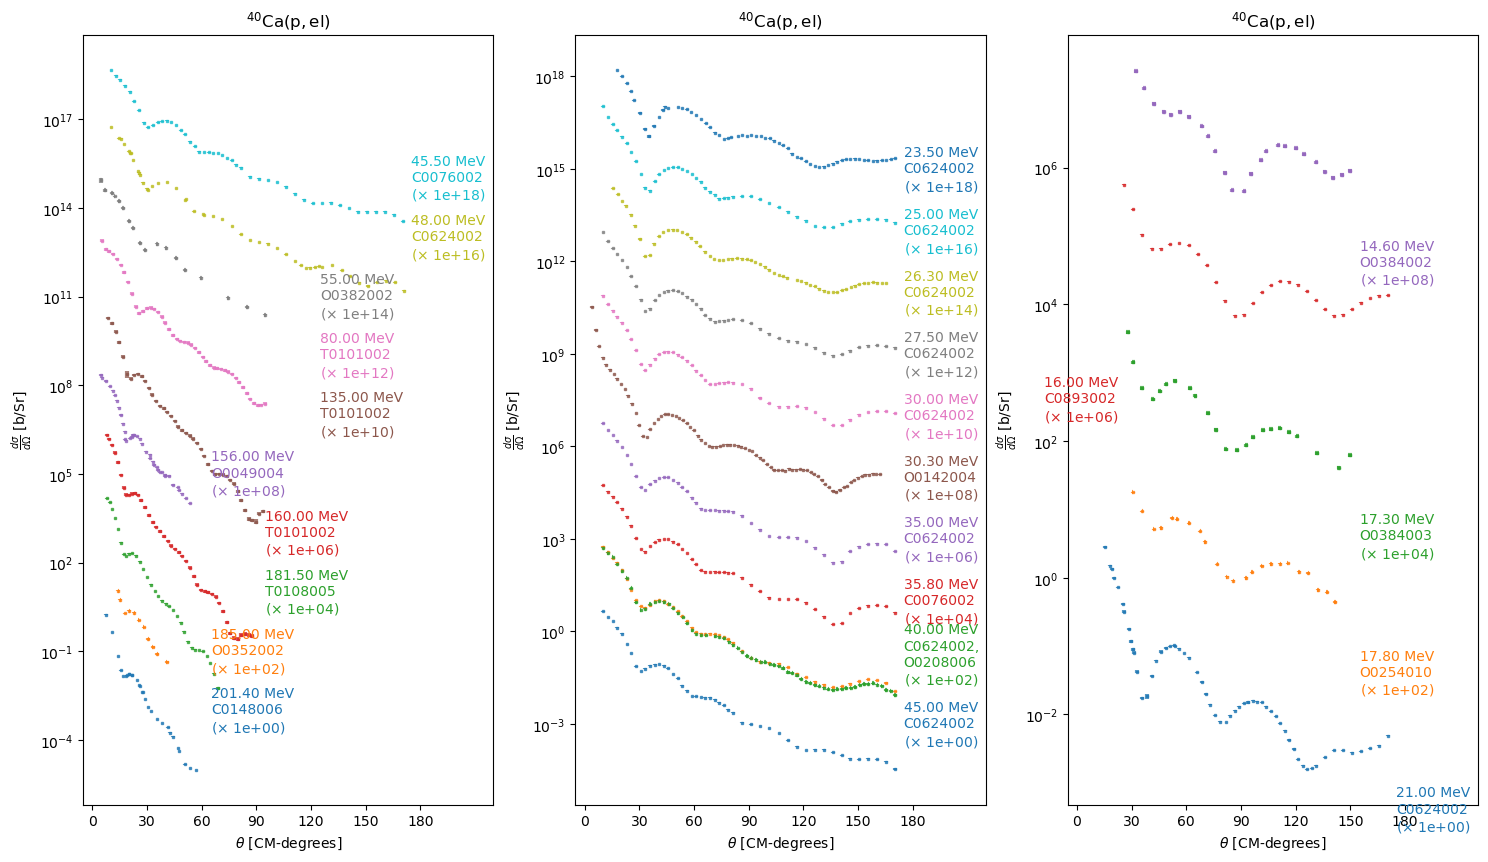

In [36]:
axes = pp_data.data["dXS/dA"].plot(
    n_per_plot=10,
    label_kwargs={
        "label_xloc_deg": None,
        "label_offset_factor": 0.0002,
        "label_offset": True,
        "label_exfor": True,
    },
    plot_kwargs={"offsets": 100},
    y_size=10,
)
[a.set_xlim([-5, 220]) for a in axes]

[(-5.0, 220.0), (-5.0, 220.0), (-5.0, 220.0)]

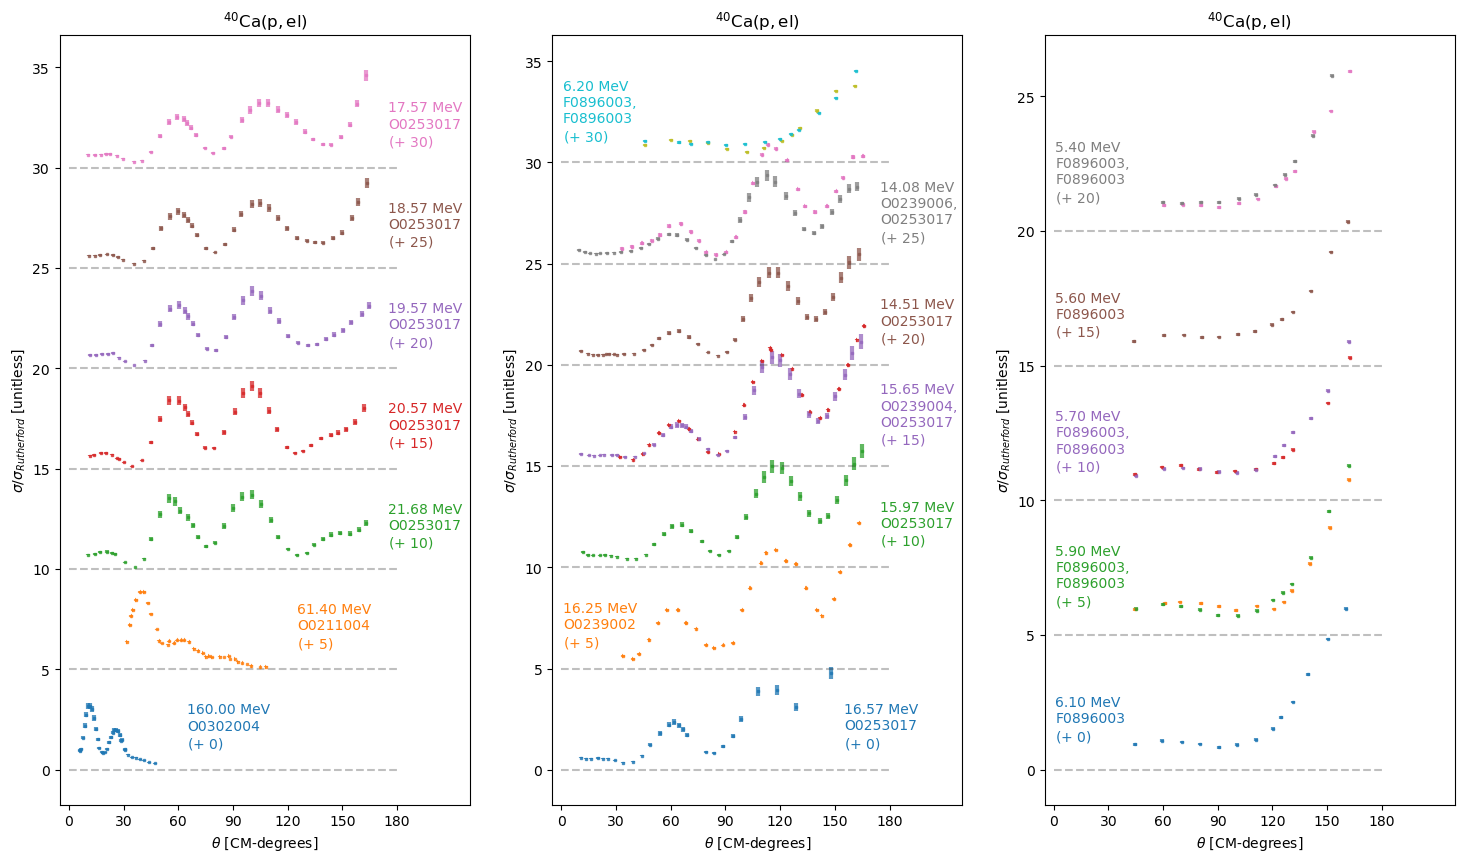

In [37]:
axes = pp_data.data["dXS/dRuth"].plot(
    n_per_plot=7,
    label_kwargs={
        "label_xloc_deg": None,
        "label_offset_factor": 1.1,
        "label_offset": True,
        "label_exfor": True,
    },
    plot_kwargs={"offsets": 5, "log": False, "draw_baseline": True},
    y_size=10,
)
[a.set_xlim([-5, 220]) for a in axes]

In [38]:
def count_data_pts(data):
    num_data_pts = 0
    num_data_sets = 0
    for entry_id, entry in data.data["dXS/dA"].entries.items():
        num_data_sets += len(entry.measurements)
        for measurement in entry.measurements:
            num_data_pts += measurement.rows
    for entry_id, entry in data.data["dXS/dRuth"].entries.items():
        num_data_sets += len(entry.measurements)

        for measurement in entry.measurements:
            num_data_pts += measurement.rows
    return num_data_pts, num_data_sets

In [39]:
num_data_pts, num_data_sets = count_data_pts(pp_data)
print(f"{num_data_pts} data points in {num_data_sets} sets ")

1735 data points in 51 sets 


# Parse compound corrections from TALYS

In [40]:
import pandas as pd

In [41]:
talys_cn_df = pd.read_csv("./data/talys_combined_data.csv")
talys_cn_df

,Angle_deg,xs_mb_sr,Direct_mb_sr,Compound_mb_sr,xs_Rutherford,Nuc_interfer,beam_energy_MeV
0,0.0,3.248300e+29,3.248300e+29,31.227040,1.000000,0.000000,5.4
1,2.0,2.023130e+08,2.023130e+08,31.227040,0.999070,-188334.300000,5.4
2,4.0,1.266223e+07,1.266220e+07,31.227040,0.999841,-2013.614000,5.4
3,6.0,2.523571e+06,2.523540e+06,31.227040,1.007760,19432.170000,5.4
4,8.0,8.053852e+05,8.053540e+05,31.227040,1.015010,11910.060000,5.4
...,...,...,...,...,...,...,...
2816,172.0,3.309627e+00,3.305040e+00,0.004587,2.473350,1.971512,20.5
2817,174.0,3.086487e+00,3.081900e+00,0.004587,2.316230,1.753939,20.5
2818,176.0,2.917507e+00,2.912920e+00,0.004587,2.195910,1.588897,20.5
2819,178.0,2.812187e+00,2.807600e+00,0.004587,2.120390,1.485927,20.5


# Set up observations and compile solvers

In [42]:
def make_observation(entry, measurement):

    # See if there's a compound correction
    data_set = talys_cn_df[talys_cn_df["beam_energy_MeV"] == measurement.Einc]
    if len(data_set) == 91:
        print(f"=> Found CN xs for {measurement.Einc} MeV")
        angles_talys_deg = data_set["Angle_deg"]
        cn_contrib_mbsr_talys = data_set["Compound_mb_sr"]
        cn_contrib = np.interp(
            measurement.x, np.deg2rad(angles_talys_deg), cn_contrib_mbsr_talys
        )
    elif len(data_set) == 0:
        print(f"=> No CN xs found for {measurement.Einc} MeV")

        cn_contrib = None
    else:
        assert False

    # compile solver
    obs = rxmc.elastic_diffxs_observation.ElasticDifferentialXSObservation(
        measurement,
        entry.reaction,
        "dXS/dRuth",
        lmax=100,
        angles_vis=angles_vis,
        ObservationClass=rxmc.observation.Observation,
        error_kwargs={
            "include_sys_norm_err": False,
            "include_sys_offset_err": False,
        },
        compound_correction=cn_contrib,
        wavelengths_beyond_range=2,
        zeros_per_node=5,
    )
    ws = obs.constraint_workspace
    print(
        f"=> Solver with E={ws.kinematics.Elab:1.2f} MeV, k={ws.kinematics.k:1.2f} fm^-1:"
    )
    print(f"  -  lmax = {ws.ls[-1,0]}")
    print(
        f"  -  channel radius = {ws.integral_workspace.channel_radius_fm:1.2f} [fm], a = channel radius * k = {ws.integral_workspace.channel_radius_fm*ws.kinematics.k:1.2f}"
    )
    print(f"  -  nodes = {ws.integral_workspace.solver.kernel.quadrature.nbasis}")
    print("\n")
    return obs

In [43]:
def make_all_observations(data):
    observations = {}
    for entry_id, entry in data.data["dXS/dA"].entries.items():
        if entry_id not in observations:
            observations[entry_id] = []
        for measurement in entry.measurements:
            if measurement.y_units in ["barns/ster", "B/Sr", "b/Sr", "B/sr", "b/sr"]:
                measurement.y_units = "b/sr"
            else:
                print(measurement.y_units)
                assert False
            observations[entry_id].append(make_observation(entry, measurement))
    for entry_id, entry in data.data["dXS/dRuth"].entries.items():
        if entry_id not in observations:
            observations[entry_id] = []
        for measurement in entry.measurements:
            assert measurement.y_units == "no-dim"
            observations[entry_id].append(make_observation(entry, measurement))
    return observations

In [44]:
%%time
print("Compiling solvers")
observations = make_all_observations(pp_data)

Compiling solvers
=> No CN xs found for 35.8 MeV
CPU times: user 649 μs, sys: 0 ns, total: 649 μs
Wall time: 614 μs


TypeError: ElasticDifferentialXSObservation.__init__() missing 4 required positional arguments: 'reaction', 'quantity', 'measurement_quantity', and 'y_units'

In [ ]:
obs_list = []
for entry, observations in observations.items():
    obs_list += observations

In [ ]:
with lzma.open(path_to_outdir / "diff_xs_observations.lz", "wb") as f:
    pickle.dump(obs_list, f)

# Analyzing powers

In [ ]:
ay_data = curate.MultiQuantityReactionData(
    rxn,
    quantities=["Ay"],
    settings={
        "Einc_range": [0, 300],
        "filter_kwargs": {"min_num_pts": 5, "allow_cos": True},
    },
    vocal=True,
)

In [ ]:
curate.print_failed_parses(ay_data.data["Ay"].failed_parses)

In [ ]:
ay_data.data["Ay"].reattempt_parse(
    "C0076",
    parsing_kwargs={"statistical_err_labels": ["ERR-S"], "systematic_err_labels": []},
)

In [ ]:
ay_data.data["Ay"].reattempt_parse(
    "O0208",
    parsing_kwargs={
        "statistical_err_labels": ["ERR-2"],
        "systematic_err_labels": ["ERR-1"],
    },
)

In [ ]:
all_data_by_entry, sys_uncertainties_by_entry = (
    curate.cross_reference_entry_systematic_err([ay_data])
)

In [ ]:
err_flag = 0.01
flagged_entries = []
for entry_id, entries in all_data_by_entry.items():
    # print(f"\n{entry_id}")
    for entry in entries:
        for measurement in entry.measurements:
            err = measurement.statistical_err
            if np.any(err < err_flag):
                flagged_entries.append(entry_id)
                print(
                    f"{measurement.subentry} for {measurement.quantity} has relative uncertainties as small as: {np.min(err):1.6f}"
                )

In [ ]:
del ay_data.data["Ay"].entries["E0166"]
del ay_data.data["Ay"].entries["E0249"]
del ay_data.data["Ay"].entries["O0032"]
del ay_data.data["Ay"].entries["O1199"]

In [ ]:
for i in range(len(ay_data.data["Ay"].entries["E1677"].measurements)):
    measurement = ay_data.data["Ay"].entries["E1677"].measurements[i]
    measurement.statistical_err = np.fabs(measurement.statistical_err)
    measurement.statistical_err[measurement.statistical_err < 0.02] = 0.02
    print(ay_data.data["Ay"].entries["E1677"].measurements[i].statistical_err)

In [ ]:
axes = ay_data.data["Ay"].plot(
    n_per_plot=6,
    label_kwargs={"label_exfor": True, "label_offset_factor": 0.0003},
    plot_kwargs={"offsets": 2, "log": False, "baseline_offset": 0},
    y_size=12,
)

# Set up observations and compile solvers

In [ ]:
def make_observation(entry, measurement):
    obs = rxmc.elastic_diffxs_observation.ElasticDifferentialXSObservation(
        measurement,
        entry.reaction,
        "Ay",
        lmax=100,
        angles_vis=angles_vis,
        ObservationClass=rxmc.observation.Observation,
        error_kwargs={
            "include_sys_norm_err": False,
            "include_sys_offset_err": False,
        },
        wavelengths_beyond_range=2,
        zeros_per_node=5,
    )
    ws = obs.constraint_workspace
    print(
        f"=> Solver with E={ws.kinematics.Elab:1.2f} MeV, k={ws.kinematics.k:1.2f} fm^-1:"
    )
    print(f"  -  lmax = {ws.ls[-1,0]}")
    print(
        f"  -  channel radius = {ws.integral_workspace.channel_radius_fm:1.2f} [fm], a = channel radius * k = {ws.integral_workspace.channel_radius_fm*ws.kinematics.k:1.2f}"
    )
    print(f"  -  nodes = {ws.integral_workspace.solver.kernel.quadrature.nbasis}")
    print("\n")

    return obs

In [ ]:
def make_all_observations(data):
    observations = {}
    for entry_id, entry in data.data["Ay"].entries.items():
        if entry_id not in observations:
            observations[entry_id] = []
        for measurement in entry.measurements:
            assert measurement.y_units == "no-dim"
            observations[entry_id].append(make_observation(entry, measurement))
    return observations

In [ ]:
%%time
print("Compiling solvers")
observations_ay = make_all_observations(ay_data)

In [ ]:
ay_obs_list = []
for entry, observations in observations_ay.items():
    ay_obs_list += observations

In [ ]:
ay_obs_list

In [ ]:
with lzma.open(path_to_outdir / "ay_observations.lz", "wb") as f:
    pickle.dump(ay_obs_list, f)

In [ ]:
beam_energies = np.sort(
    np.unique(
        [obs.constraint_workspace.kinematics.Elab for obs in obs_list + ay_obs_list]
    )
)

In [ ]:
for E in beam_energies:
    print(f"{E:1.3f},")